# Data Cleaning and Feature Preparation

## Overview
This notebook performs the data preprocessing and feature preparation for the **AI-Based Resume Screening and Hiring Prediction System** project. The goal of this step is to transform the raw resume dataset into a clean and structured format that can be used for machine learning models.

The primary task of this project is to predict whether a candidate should be hired or rejected (binary classification) based on resume information such as skills, education, certifications, years of experience, and Projects Count. 

## Dataset
The dataset used in this project is the **AI-Powered Resume Screening Dataset (2025)** from Kaggle. It contains approximately 1000 candidate resumes with a mixture of structured and semi-structured features.

## Objectives of This Notebook
The purpose of this notebook is to prepare the dataset for modeling by performing the following steps:

1. **Load and inspect the dataset**
2. **Clean the data** (handle missing values, remove unnecessary columns)
3. **Detect and handle outliers** in numeric features
4. **Encode categorical variables**
5. **Convert text features into numerical representations using TF-IDF**
6. **Perform feature engineering when necessary**
7. **Split the data into training and testing sets**

The processed dataset produced in this notebook will be used in the next stage of the project:  
`Modeling_and_Evaluation.ipynb`.

## Setup

In [94]:
# === Imports === #
import os
import re
import json
import joblib
from scipy.sparse import save_npz 

import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer

from scipy import sparse

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)

# Reproducibility
RANDOM_STATE = 42

## 1. Load and inspect the dataset

In [95]:
# === Data path ===
# Update the path if the dataset is stored somewhere else
DATA_PATH = "AI_Resume_Screening.csv"

# Load dataset
df = pd.read_csv(DATA_PATH)

# Display basic information
display(df.head())
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100)
0,1,Ashley Ali,"TensorFlow, NLP, Pytorch",10,B.Sc,NaN,AI Researcher,Hire,104895,8,100
1,2,Wesley Roman,"Deep Learning, Machine Learning, Python, SQL",10,MBA,Google ML,Data Scientist,Hire,113002,1,100
2,3,Corey Sanchez,"Ethical Hacking, Cybersecurity, Linux",1,MBA,Deep Learning Specialization,Cybersecurity Analyst,Hire,71766,7,70
3,4,Elizabeth Carney,"Python, Pytorch, TensorFlow",7,B.Tech,AWS Certified,AI Researcher,Hire,46848,0,95
4,5,Julie Hill,"SQL, React, Java",4,PhD,NaN,Software Engineer,Hire,87441,9,100


Shape: (1000, 11)
Columns: ['Resume_ID', 'Name', 'Skills', 'Experience (Years)', 'Education', 'Certifications', 'Job Role', 'Recruiter Decision', 'Salary Expectation ($)', 'Projects Count', 'AI Score (0-100)']


In [96]:
# Basic dataset structure
df.info()

# Summary Statistics
display(df.describe(include="all").T.head(30))

# Missing Value Analysis
missing = df.isna().mean().sort_values(ascending=False)
missing = missing[missing > 0] # Keep only columns with missing values
print("Missing columns:", len(missing))
display(missing.to_frame("missing_rate").head(30))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Resume_ID               1000 non-null   int64 
 1   Name                    1000 non-null   object
 2   Skills                  1000 non-null   object
 3   Experience (Years)      1000 non-null   int64 
 4   Education               1000 non-null   object
 5   Certifications          726 non-null    object
 6   Job Role                1000 non-null   object
 7   Recruiter Decision      1000 non-null   object
 8   Salary Expectation ($)  1000 non-null   int64 
 9   Projects Count          1000 non-null   int64 
 10  AI Score (0-100)        1000 non-null   int64 
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Resume_ID,1000.0,NaN,NaN,NaN,500.5,288.819436,1.0,250.75,500.5,750.25,1000.0
Name,1000,989,Sarah Jones,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Skills,1000,238,"Python, Machine Learning",11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Experience (Years),1000.0,NaN,NaN,NaN,4.896,3.112695,0.0,2.0,5.0,8.0,10.0
Education,1000,5,B.Sc,205,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Certifications,726,3,Deep Learning Specialization,255,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job Role,1000,4,AI Researcher,257,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Recruiter Decision,1000,2,Hire,812,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Salary Expectation ($),1000.0,NaN,NaN,NaN,79994.486,23048.472549,40085.0,60415.75,79834.5,99583.25,119901.0
Projects Count,1000.0,NaN,NaN,NaN,5.133,3.23137,0.0,2.0,5.0,8.0,10.0


Missing columns: 1


,missing_rate
Certifications,0.274


### Observations from Initial Data Inspection
1. **Dataset size**
   - The dataset contains 1000 samples and 11 columns.

2. **Data types**
   - There are 5 numeric features and 6 categorical/text features.
   - Text-related fields include Skills, Certifications, Education, and Job Role.

3. **Missing values**
   - The **Certifications** column contains missing values.
   - Other columns appear to have no missing values.

4. **Identifier columns**
   - `Resume_ID` and `Name` appear to be identifiers rather than useful predictive features, so they will be removed during preprocessing.

5. **Target variable**
   - The target variable is **Recruiter Decision**, which has two classes (Hire / Reject).
   - The dataset appears imbalanced, with Hire being the majority class (812 out of 1000).

6. **Numeric feature ranges**
   - Experience (Years) ranges from **0 to 10 years**, with an average of about **4.9 years**.
   - Projects Count ranges from **0 to 10 projects**, with an average of about **5.1 projects**.
   - Salary Expectation ranges from about 40k to 120k.

## 2. Clean the data (handle missing values, remove unnecessary columns)

In [97]:
# === Drop identifier columns ===
drop_cols = ["Resume_ID", "Name"]

for col in drop_cols:
    if col in df.columns:
        df = df.drop(columns=[col])

# === Handle missing values ===
df["Certifications"] = df["Certifications"].fillna("")

# === Separate target and features ===
y = df["Recruiter Decision"]
X = df.drop(columns=["Recruiter Decision"])

display(X.head())
print("Feature shape:", X.shape)
print("Target shape:", y.shape)

,Skills,Experience (Years),Education,Certifications,Job Role,Salary Expectation ($),Projects Count,AI Score (0-100)
0,"TensorFlow, NLP, Pytorch",10,B.Sc,,AI Researcher,104895,8,100
1,"Deep Learning, Machine Learning, Python, SQL",10,MBA,Google ML,Data Scientist,113002,1,100
2,"Ethical Hacking, Cybersecurity, Linux",1,MBA,Deep Learning Specialization,Cybersecurity Analyst,71766,7,70
3,"Python, Pytorch, TensorFlow",7,B.Tech,AWS Certified,AI Researcher,46848,0,95
4,"SQL, React, Java",4,PhD,,Software Engineer,87441,9,100


Feature shape: (1000, 8)
Target shape: (1000,)


## 3. Detect and handle outliers in numeric features

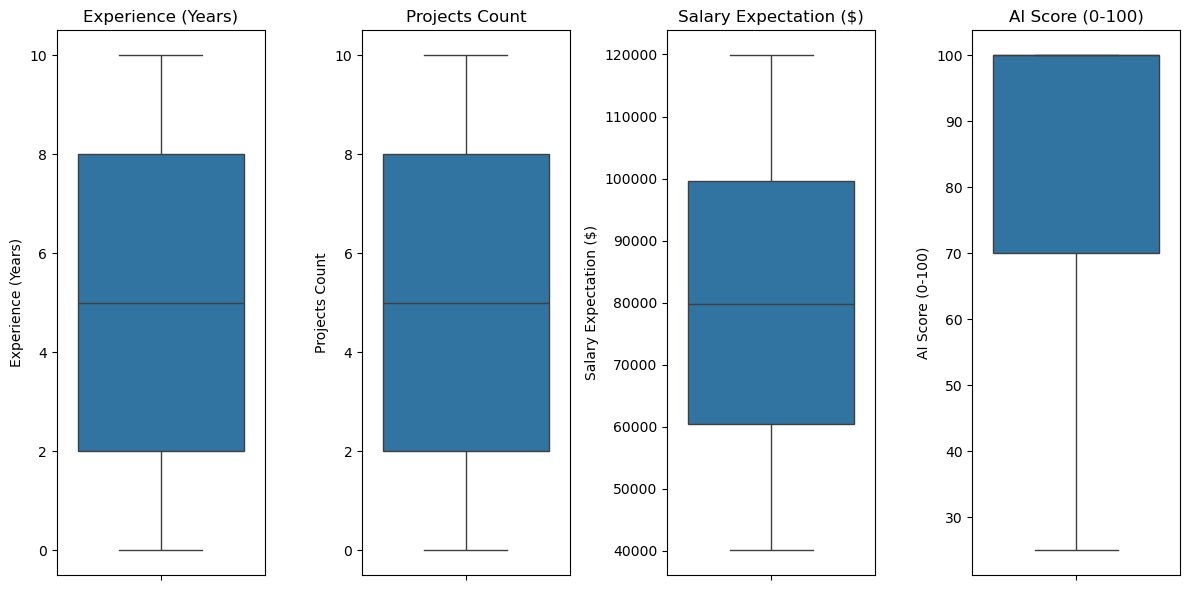

Outlier handling completed using IQR clipping.


,Experience (Years),Projects Count,Salary Expectation ($),AI Score (0-100)
count,1000.000000,1000.00000,1000.000000,1000.000000
mean,4.896000,5.13300,79994.486000,83.990000
std,3.112695,3.23137,23048.472549,20.863009
min,0.000000,0.00000,40085.000000,25.000000
25%,2.000000,2.00000,60415.750000,70.000000
50%,5.000000,5.00000,79834.500000,100.000000
75%,8.000000,8.00000,99583.250000,100.000000
max,10.000000,10.00000,119901.000000,100.000000


In [99]:
# Numeric columns to inspect
numeric_cols = [
    "Experience (Years)",
    "Projects Count",
    "Salary Expectation ($)",
    "AI Score (0-100)"
]

numeric_cols = [c for c in numeric_cols if c in X.columns]

# --- Visualization: boxplots to inspect potential outliers ---
plt.figure(figsize=(12, 6))
for i, col in enumerate(numeric_cols):
    plt.subplot(1, len(numeric_cols), i + 1)
    sns.boxplot(y=X[col])
    plt.title(col)
plt.tight_layout()
plt.show()

# --- Detect and handle outliers using IQR clipping ---
for col in numeric_cols:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Clip extreme values
    X[col] = X[col].clip(lower_bound, upper_bound)

print("Outlier handling completed using IQR clipping.")
display(X[numeric_cols].describe())

## 4. Encode categorical variables

In [100]:
# Categorical columns
cat_cols = ["Education", "Job Role"]

cat_cols = [c for c in cat_cols if c in X.columns]

# Create encoder 
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

# Fit and transform
encoded_array = encoder.fit_transform(X[cat_cols])

# Convert to DataFrame
encoded_df = pd.DataFrame(
    encoded_array,
    columns=encoder.get_feature_names_out(cat_cols),
    index=X.index
)

# Replace original categorical columns
X = pd.concat([X.drop(columns=cat_cols), encoded_df], axis=1)

print("Categorical variables encoded.")
print("New feature shape:", X.shape)

display(X.head())

Categorical variables encoded.
New feature shape: (1000, 15)


,Skills,Experience (Years),Certifications,Salary Expectation ($),Projects Count,AI Score (0-100),Education_B.Sc,Education_B.Tech,Education_M.Tech,Education_MBA,Education_PhD,Job Role_AI Researcher,Job Role_Cybersecurity Analyst,Job Role_Data Scientist,Job Role_Software Engineer
0,"TensorFlow, NLP, Pytorch",10,,104895,8,100,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,"Deep Learning, Machine Learning, Python, SQL",10,Google ML,113002,1,100,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,"Ethical Hacking, Cybersecurity, Linux",1,Deep Learning Specialization,71766,7,70,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,"Python, Pytorch, TensorFlow",7,AWS Certified,46848,0,95,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,"SQL, React, Java",4,,87441,9,100,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


## 5. Convert text features into numerical representations using TF-IDF

In [101]:
# Text columns
text_cols = ["Skills", "Certifications"]
text_cols = [c for c in text_cols if c in X.columns]

# Fill missing just in case (TF-IDF cannot handle NaN)
for col in text_cols:
    X[col] = X[col].fillna("").astype(str)

# Combine text into one field (simple + effective)
X["text_all"] = X[text_cols].agg(" ".join, axis=1)

# Fit TF-IDF on the combined text
tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=5000,   # adjust if you want (e.g., 2000–10000)
    ngram_range=(1, 2)   # unigrams + bigrams
)

tfidf_matrix = tfidf.fit_transform(X["text_all"])

# Convert sparse TF-IDF matrix to a DataFrame
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=[f"tfidf_{t}" for t in tfidf.get_feature_names_out()],
    index=X.index
)

# Drop original text columns and the combined text column, then append TF-IDF features
X = pd.concat([X.drop(columns=text_cols + ["text_all"]), tfidf_df], axis=1)

print("TF-IDF conversion complete.")
print("New feature shape:", X.shape)
display(X.head())

TF-IDF conversion complete.
New feature shape: (1000, 112)


,Experience (Years),Salary Expectation ($),Projects Count,AI Score (0-100),Education_B.Sc,Education_B.Tech,Education_M.Tech,Education_MBA,Education_PhD,Job Role_AI Researcher,Job Role_Cybersecurity Analyst,Job Role_Data Scientist,Job Role_Software Engineer,tfidf_aws,tfidf_aws certified,tfidf_certified,tfidf_cybersecurity,tfidf_cybersecurity aws,tfidf_cybersecurity deep,tfidf_cybersecurity ethical,tfidf_cybersecurity google,tfidf_cybersecurity linux,tfidf_cybersecurity networking,tfidf_deep,tfidf_deep learning,tfidf_ethical,tfidf_ethical hacking,tfidf_google,tfidf_google ml,tfidf_hacking,tfidf_hacking aws,tfidf_hacking cybersecurity,tfidf_hacking deep,tfidf_hacking google,tfidf_hacking linux,tfidf_hacking networking,tfidf_java,tfidf_java aws,tfidf_java deep,tfidf_java google,tfidf_java react,tfidf_java sql,tfidf_learning,tfidf_learning aws,tfidf_learning deep,tfidf_learning google,tfidf_learning machine,tfidf_learning python,tfidf_learning specialization,tfidf_learning sql,tfidf_linux,tfidf_linux aws,tfidf_linux cybersecurity,tfidf_linux deep,tfidf_linux ethical,tfidf_linux google,tfidf_linux networking,tfidf_machine,tfidf_machine learning,tfidf_ml,tfidf_networking,tfidf_networking aws,tfidf_networking cybersecurity,tfidf_networking deep,tfidf_networking ethical,tfidf_networking google,tfidf_networking linux,tfidf_nlp,tfidf_nlp aws,tfidf_nlp deep,tfidf_nlp google,tfidf_nlp python,tfidf_nlp pytorch,tfidf_nlp tensorflow,tfidf_python,tfidf_python aws,tfidf_python deep,tfidf_python google,tfidf_python machine,tfidf_python nlp,tfidf_python pytorch,tfidf_python sql,tfidf_python tensorflow,tfidf_pytorch,tfidf_pytorch aws,tfidf_pytorch deep,tfidf_pytorch google,tfidf_pytorch nlp,tfidf_pytorch python,tfidf_pytorch tensorflow,tfidf_react,tfidf_react aws,tfidf_react deep,tfidf_react google,tfidf_react java,tfidf_react sql,tfidf_specialization,tfidf_sql,tfidf_sql aws,tfidf_sql deep,tfidf_sql google,tfidf_sql java,tfidf_sql machine,tfidf_sql python,tfidf_sql react,tfidf_tensorflow,tfidf_tensorflow aws,tfidf_tensorflow deep,tfidf_tensorflow google,tfidf_tensorflow nlp,tfidf_tensorflow python,tfidf_tensorflow pytorch
0,10,104895,8,100,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.00000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.00000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.364987,0.0,0.0,0.0,0.0,0.56311,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.369301,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.358083,0.000000,0.0,0.0,0.533933,0.0,0.0
1,10,113002,1,100,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.172188,0.172188,0.00000,0.00000,0.224369,0.224369,0.00000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.326830,0.0,0.0,0.0,0.374108,0.30476,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.233685,0.233685,0.224369,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.00000,0.0,0.174464,0.0,0.0,0.0,0.0,0.0,0.000000,0.369936,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.178714,0.0,0.0,0.376269,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0
2,1,71766,7,70,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.000000,0.000000,0.000000,0.246315,0.0,0.0,0.0,0.0,0.401522,0.0,0.175894,0.175894,0.23602,0.23602,0.000000,0.000000,0.23602,0.0,0.396285,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.166933,0.0,0.0,0.0,0.000000,0.00000,0.216555,0.0,0.242912,0.0,0.0,0.459792,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.00000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.216555,0.000000,0.0,0.0,0.000000,0.0,0.0,

## 6. Perform feature engineering when necessary

In [103]:
# Experience per project
if "Experience (Years)" in X.columns and "Projects Count" in X.columns:
    X["experience_per_project"] = X["Experience (Years)"] / (X["Projects Count"] + 1)

# Project productivity
if "Experience (Years)" in X.columns and "Projects Count" in X.columns:
    X["projects_per_year"] = X["Projects Count"] / (X["Experience (Years)"] + 1)

# Log transform salary expectation 
# helps reduce skewness
if "Salary Expectation ($)" in X.columns:
    X["log_salary_expectation"] = np.log1p(X["Salary Expectation ($)"])

print("Feature engineering completed.")
print("New feature shape:", X.shape)

display(X.head())

Feature engineering completed.
New feature shape: (1000, 115)


,Experience (Years),Salary Expectation ($),Projects Count,AI Score (0-100),Education_B.Sc,Education_B.Tech,Education_M.Tech,Education_MBA,Education_PhD,Job Role_AI Researcher,Job Role_Cybersecurity Analyst,Job Role_Data Scientist,Job Role_Software Engineer,tfidf_aws,tfidf_aws certified,tfidf_certified,tfidf_cybersecurity,tfidf_cybersecurity aws,tfidf_cybersecurity deep,tfidf_cybersecurity ethical,tfidf_cybersecurity google,tfidf_cybersecurity linux,tfidf_cybersecurity networking,tfidf_deep,tfidf_deep learning,tfidf_ethical,tfidf_ethical hacking,tfidf_google,tfidf_google ml,tfidf_hacking,tfidf_hacking aws,tfidf_hacking cybersecurity,tfidf_hacking deep,tfidf_hacking google,tfidf_hacking linux,tfidf_hacking networking,tfidf_java,tfidf_java aws,tfidf_java deep,tfidf_java google,tfidf_java react,tfidf_java sql,tfidf_learning,tfidf_learning aws,tfidf_learning deep,tfidf_learning google,tfidf_learning machine,tfidf_learning python,tfidf_learning specialization,tfidf_learning sql,tfidf_linux,tfidf_linux aws,tfidf_linux cybersecurity,tfidf_linux deep,tfidf_linux ethical,tfidf_linux google,tfidf_linux networking,tfidf_machine,tfidf_machine learning,tfidf_ml,tfidf_networking,tfidf_networking aws,tfidf_networking cybersecurity,tfidf_networking deep,tfidf_networking ethical,tfidf_networking google,tfidf_networking linux,tfidf_nlp,tfidf_nlp aws,tfidf_nlp deep,tfidf_nlp google,tfidf_nlp python,tfidf_nlp pytorch,tfidf_nlp tensorflow,tfidf_python,tfidf_python aws,tfidf_python deep,tfidf_python google,tfidf_python machine,tfidf_python nlp,tfidf_python pytorch,tfidf_python sql,tfidf_python tensorflow,tfidf_pytorch,tfidf_pytorch aws,tfidf_pytorch deep,tfidf_pytorch google,tfidf_pytorch nlp,tfidf_pytorch python,tfidf_pytorch tensorflow,tfidf_react,tfidf_react aws,tfidf_react deep,tfidf_react google,tfidf_react java,tfidf_react sql,tfidf_specialization,tfidf_sql,tfidf_sql aws,tfidf_sql deep,tfidf_sql google,tfidf_sql java,tfidf_sql machine,tfidf_sql python,tfidf_sql react,tfidf_tensorflow,tfidf_tensorflow aws,tfidf_tensorflow deep,tfidf_tensorflow google,tfidf_tensorflow nlp,tfidf_tensorflow python,tfidf_tensorflow pytorch,experience_per_project,projects_per_year,log_salary_expectation
0,10,104895,8,100,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.00000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.00000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.364987,0.0,0.0,0.0,0.0,0.56311,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.369301,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.358083,0.000000,0.0,0.0,0.533933,0.0,0.0,1.111111,0.727273,11.560725
1,10,113002,1,100,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.172188,0.172188,0.00000,0.00000,0.224369,0.224369,0.00000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.326830,0.0,0.0,0.0,0.374108,0.30476,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.233685,0.233685,0.224369,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.00000,0.0,0.174464,0.0,0.0,0.0,0.0,0.0,0.000000,0.369936,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.000000,0.178714,0.0,0.0,0.376269,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,5.000000,0.090909,11.635170
2,1,71766,7,70,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.000000,0.000000,0.000000,0.246315,0.0,0.0,0.0,0.0,0.401522,0.0,0.175894,0.175894,0.23602,0.23602,0.000000,0.000000,0.23602,0.0,0.396285,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.166933,0.0,0.0,0.0,0.000000,0.00000,0.216555,0.0,0.242912,0.0,0.0,0.459792,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.00000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000

## 7. Split the data into training and testing sets

In [105]:
# Perform stratified split to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,      # 80% train, 20% test
    random_state=42, 
    stratify=y 
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training set shape: (800, 115)
Testing set shape: (200, 115)

Training target distribution:
Recruiter Decision
Hire      0.8125
Reject    0.1875
Name: proportion, dtype: float64

Testing target distribution:
Recruiter Decision
Hire      0.81
Reject    0.19
Name: proportion, dtype: float64


- The processed dataset produced in this notebook will be used in the next stage of the project:  
`Modeling_and_Evaluation.ipynb`.

In [106]:
# === Save processed features for the next notebook ===
# Create output folder
OUT_DIR = "data/processed"
os.makedirs(OUT_DIR, exist_ok=True)

# Save feature matrices
X_train.to_parquet(os.path.join(OUT_DIR, "X_train.parquet"), index=False)
X_test.to_parquet(os.path.join(OUT_DIR, "X_test.parquet"), index=False)

# Save labels
y_train.to_frame(name="target").to_parquet(os.path.join(OUT_DIR, "y_train.parquet"), index=False)
y_test.to_frame(name="target").to_parquet(os.path.join(OUT_DIR, "y_test.parquet"), index=False)